In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df2 = pd.read_csv('/content/data.csv', encoding='latin1')
df2.head()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338924 entries, 0 to 338923
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    338924 non-null  object 
 1   StockCode    338924 non-null  object 
 2   Description  337739 non-null  object 
 3   Quantity     338923 non-null  float64
 4   InvoiceDate  338923 non-null  object 
 5   UnitPrice    338923 non-null  float64
 6   CustomerID   246728 non-null  float64
 7   Country      338923 non-null  object 
dtypes: float64(3), object(5)
memory usage: 20.7+ MB


In [4]:
# Drop rows with missing CustomerID
df2 = df2.dropna(subset=['CustomerID'])

# Remove returns/cancellations (negative quantity)
df2 = df2[df2['Quantity'] > 0]

# Remove rows with missing/zero UnitPrice
df2 = df2[df2['UnitPrice'] > 0]

# Convert InvoiceDate to datetime
df2['InvoiceDate'] = pd.to_datetime(df2['InvoiceDate'])

# Create a TotalPrice column (needed for Monetary)
df2['TotalPrice'] = df2['Quantity'] * df2['UnitPrice']

df2.info()
df2.shape

<class 'pandas.core.frame.DataFrame'>
Index: 240889 entries, 0 to 338922
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    240889 non-null  object        
 1   StockCode    240889 non-null  object        
 2   Description  240889 non-null  object        
 3   Quantity     240889 non-null  float64       
 4   InvoiceDate  240889 non-null  datetime64[ns]
 5   UnitPrice    240889 non-null  float64       
 6   CustomerID   240889 non-null  float64       
 7   Country      240889 non-null  object        
 8   TotalPrice   240889 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 18.4+ MB


(240889, 9)

In [5]:
import datetime as dt

# Set a reference date (one day after the last transaction in the dataset)
reference_date = df2['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df2.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                         # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()
rfm.describe()

,Recency,Frequency,Monetary
count,3402.000000,3402.000000,3402.000000
mean,95.234274,3.551440,1630.483590
std,81.211516,5.817965,6210.459793
min,1.000000,1.000000,2.900000
25%,26.000000,1.000000,267.165000
50%,72.000000,2.000000,571.285000
75%,152.000000,4.000000,1406.387500
max,287.000000,133.000000,186583.740000


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.770523,-0.438610,12.167251
12347.0,-0.643283,0.249017,0.186870
12348.0,0.822242,-0.094796,-0.023068
12350.0,1.573478,-0.438610,-0.208724
12352.0,0.982342,0.249017,-0.011059


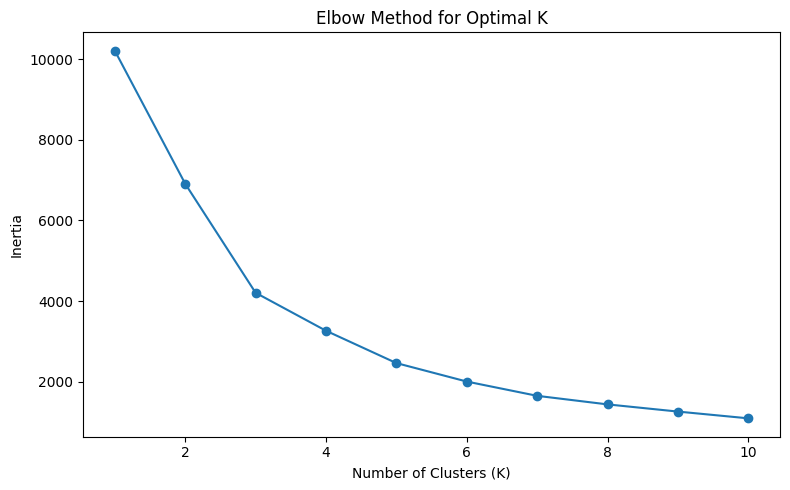

In [7]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

**Observation:** Inertia drops sharply up to K=4, then flattens out —
indicating 4 clusters is the optimal choice, balancing model simplicity
with meaningful segmentation.

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,239,1,77183.60,2
12347.0,43,5,2790.86,0
12348.0,162,3,1487.24,1
12350.0,223,1,334.40,1
12352.0,175,5,1561.81,1


**Observation:** Clusters separate clearly along both axes — customers
with low recency (recently active) and high monetary value form a
distinct high-value group, while high-recency, low-monetary customers
cluster separately as lapsed/at-risk buyers.

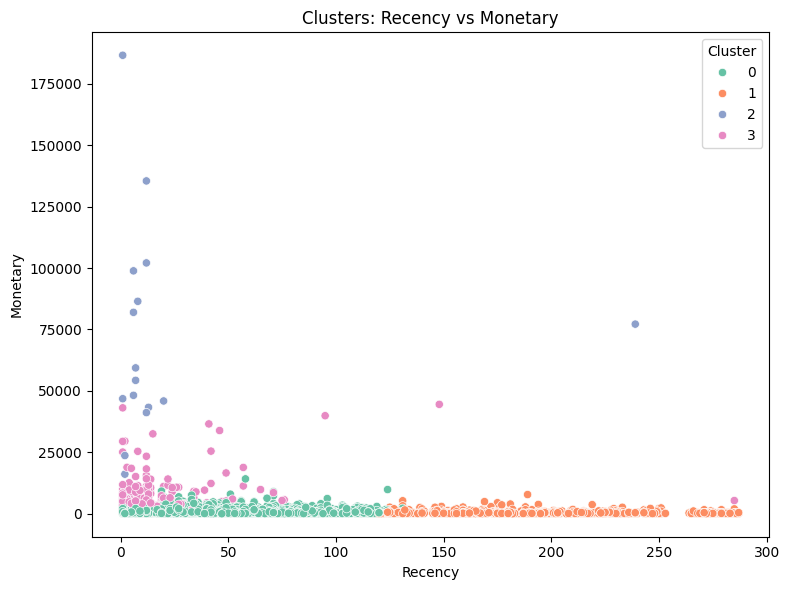

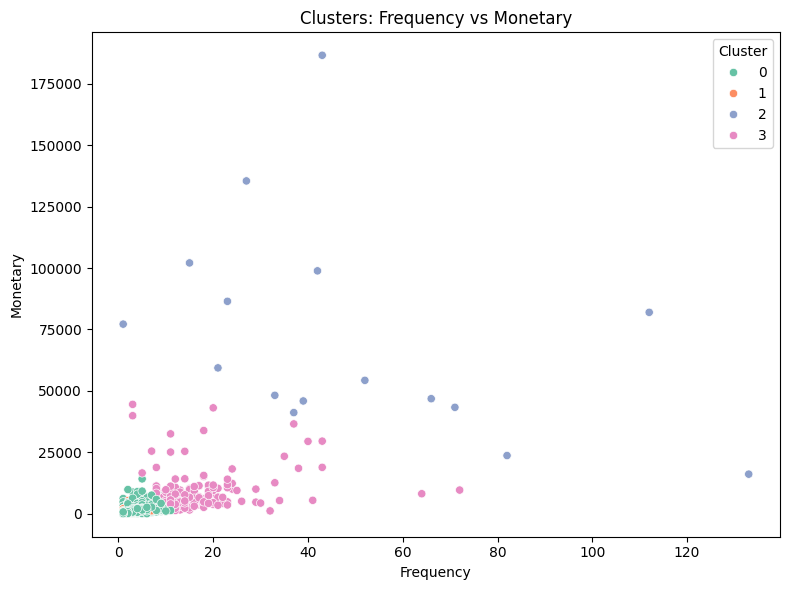

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set2')
plt.title('Clusters: Recency vs Monetary')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2')
plt.title('Clusters: Frequency vs Monetary')
plt.tight_layout()
plt.show()

**Observation:** A small cluster of customers with very high frequency
and monetary value stands apart from the rest, confirming a distinct
"VIP" segment that drives disproportionate revenue despite being a tiny
fraction of the customer base.

In [10]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)
cluster_profile['Count'] = rfm['Cluster'].value_counts()
cluster_profile

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,49.7,3.2,1126.6,2103
1,196.5,1.4,456.0,1098
2,22.1,49.8,71724.1,16
3,18.2,16.5,8267.0,185


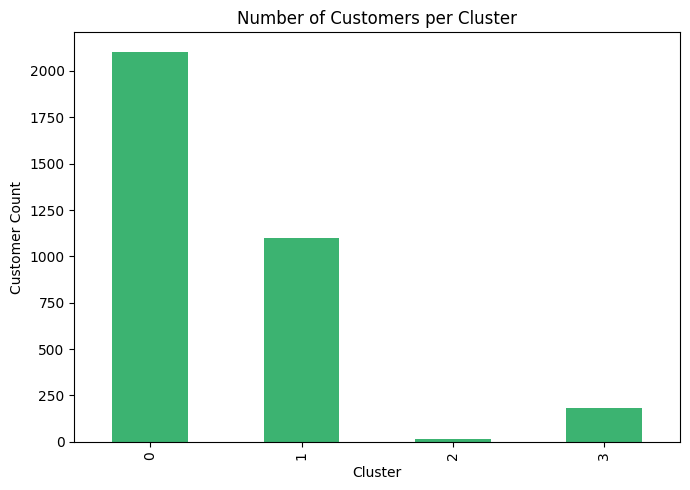

In [11]:
plt.figure(figsize=(7,5))
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color='mediumseagreen')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

**Observation:** Cluster 2 (16 customers) generates extremely high average
spend (₹71,724) and purchase frequency (50), while Cluster 1 (1,098
customers) shows long recency (197 days) and low spend, marking them as
inactive or churned customers.

## Insights: Recommended Marketing Actions per Segment

- **Cluster 0 – Regular customers (2,103):** Nurture with loyalty programs
  and consistent engagement emails to gradually shift them toward higher
  frequency and spend, similar to Cluster 3's behavior.

- **Cluster 1 – At-risk/lapsed customers (1,098):** Launch win-back
  campaigns — targeted discount codes or "we miss you" emails referencing
  their past purchases — to re-activate before they churn completely.

- **Cluster 2 – VIP customers (16):** Provide white-glove treatment:
  dedicated account management, early access to new products, and personal
  outreach. Though tiny in number, this group drives outsized revenue and
  deserves retention priority.

- **Cluster 3 – Loyal high-value customers (185):** Focus on upsell and
  cross-sell opportunities plus referral incentives. This is a reliable,
  high-value base worth protecting and growing.
  



## **TASK 3 - CLEANING DATA**

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df3 = pd.read_csv('/content/us-shein-mens_clothes-1891.csv')
df3.head()
df3.info()
df3.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1890 entries, 0 to 1889
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   color-count          1141 non-null   float64
 1   goods-title-link     1889 non-null   object 
 2   selling_proposition  1277 non-null   object 
 3   price                1889 non-null   object 
 4   discount             1860 non-null   object 
 5   rank-title           560 non-null    object 
 6   rank-sub             560 non-null    object 
dtypes: float64(1), object(6)
memory usage: 103.5+ KB


,0
color-count,749
goods-title-link,1
selling_proposition,613
price,1
discount,30
rank-title,1330
rank-sub,1330


In [6]:
quality_report = pd.DataFrame({
    'Nulls': df3.isnull().sum(),
    'Null %': (df3.isnull().sum() / len(df3) * 100).round(1),
    'Dtype': df3.dtypes,
    'Unique Values': df3.nunique()
})
print(quality_report)
print(f"\nDuplicate rows: {df3.duplicated().sum()}")
print(f"Total rows: {len(df3)}")

                     Nulls  Null %    Dtype  Unique Values
color-count            749    39.6  float64             19
goods-title-link         1     0.1   object           1631
selling_proposition    613    32.4   object             87
price                    1     0.1   object            604
discount                30     1.6   object             67
rank-title            1330    70.4   object             19
rank-sub              1330    70.4   object            376

Duplicate rows: 86
Total rows: 1890


In [7]:
print(df3['price'].head(10))
print(df3['discount'].head(10))

0    $11.99
1    $11.19
2     $8.09
3     $9.99
4     $3.48
5    $24.69
6    $22.79
7     $4.10
8     $7.99
9    $23.95
Name: price, dtype: object
0     -7%
1    -13%
2    -13%
3    -12%
4    -70%
5    -12%
6     -7%
7    -56%
8    -13%
9    -14%
Name: discount, dtype: object


In [10]:
print(df3['price'].head(10))
print(df3['discount'].head(10))

0    11.99
1    11.19
2     8.09
3     9.99
4     3.48
5    24.69
6    22.79
7     4.10
8     7.99
9    23.95
Name: price, dtype: float64
0     7.0
1    13.0
2    13.0
3    12.0
4    70.0
5    12.0
6     7.0
7    56.0
8    13.0
9    14.0
Name: discount, dtype: float64


In [12]:
# Clean price
df3['price'] = df3['price'].astype(str).str.replace('$', '', regex=False)
df3['price'] = pd.to_numeric(df3['price'], errors='coerce')

# Clean discount
df3['discount'] = df3['discount'].astype(str).str.replace('%', '', regex=False).str.replace('-', '', regex=False)
df3['discount'] = pd.to_numeric(df3['discount'], errors='coerce')

df3[['price', 'discount']].head(10)
df3[['price', 'discount']].describe()

,price,discount
count,1889.000000,1860.000000
mean,12.294087,18.246237
std,5.766049,14.584237
min,2.800000,5.000000
25%,8.390000,8.000000
50%,11.080000,13.000000
75%,15.090000,18.000000
max,61.290000,87.000000


In [15]:

df3['price'] = df3['price'].fillna(df3['price'].median())

df3['discount'] = df3['discount'].fillna(0)

df3['color-count'] = df3['color-count'].fillna(1)

df3['selling_proposition'] = df3['selling_proposition'].fillna('None')

df3['rank-title'] = df3['rank-title'].fillna('Not Ranked')

df3['rank-sub'] = df3['rank-sub'].fillna('Not Ranked')

df3 = df3.dropna(subset=['goods-title-link'])

df3.isnull().sum()

,0
color-count,0
goods-title-link,0
selling_proposition,0
price,0
discount,0
rank-title,0
rank-sub,0


**Missing Data Strategy:**
- Price (1 null): Filled with median — negligible impact, avoids losing a row.
- Discount (30 nulls): Filled with 0 — absence of a discount value likely means no promotion was applied.
- Color-count (749 nulls): Filled with 1 — likely represents single-variant products where color count wasn't tracked.
- Selling proposition (613 nulls): Filled with 'None' — this is an optional marketing tag; absence is meaningful, not an error.
- Rank-title/Rank-sub (~1330 nulls each): Filled with 'Not Ranked' — most products aren't part of a bestseller ranking list.
- Goods-title-link (1 null): Row dropped — this is the core product identifier; can't be meaningfully imputed.

In [16]:
dupes_before = df3.duplicated().sum()
df3 = df3.drop_duplicates()
print(f"Duplicates removed: {dupes_before}")
print(f"Remaining rows: {len(df3)}")

Duplicates removed: 86
Remaining rows: 1803


In [17]:
print(df3['selling_proposition'].unique())
print(df3['rank-title'].unique())

['10k+ sold recently' 'None' '30+ sold recently' '80+ sold recently'
 '3.8k+ sold recently' '100+ sold recently' '500+ sold recently'
 '600+ sold recently' '800+ sold recently' '10+ sold recently'
 '1.0k+ sold recently' '1.3k+ sold recently' '20+ sold recently'
 '6.8k+ sold recently' '1.2k+ sold recently' '1.6k+ sold recently'
 '3.0k+ sold recently' '6.3k+ sold recently' '300+ sold recently'
 '1.7k+ sold recently' '3.2k+ sold recently' '4.7k+ sold recently'
 '1.8k+ sold recently' '6.0k+ sold recently' '5.9k+ sold recently'
 '50+ sold recently' '2.3k+ sold recently' '40+ sold recently'
 '3.9k+ sold recently' '7.6k+ sold recently' '6.5k+ sold recently'
 '2.6k+ sold recently' '200+ sold recently' '5.3k+ sold recently'
 '1.1k+ sold recently' '4.3k+ sold recently' '5.0k+ sold recently'
 '1.5k+ sold recently' '900+ sold recently' '6.2k+ sold recently'
 '6.1k+ sold recently' '2.7k+ sold recently' '3.3k+ sold recently'
 '2.8k+ sold recently' '2.9k+ sold recently' '2.5k+ sold recently'
 '3.6k+ 

In [18]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    print(f"{column}: {len(outliers)} outliers (bounds: {lower:.2f} to {upper:.2f})")
    return outliers

price_outliers = detect_outliers_iqr(df3, 'price')
discount_outliers = detect_outliers_iqr(df3, 'discount')

price: 42 outliers (bounds: -1.67 to 25.15)
discount: 279 outliers (bounds: -9.50 to 34.50)


**Outlier Decision:** Price outliers (42 items, above $25.15) and discount
outliers (279 items, above 34.5%) were both retained rather than removed.
These represent genuine premium-priced products and legitimate deep-discount
promotions respectively — common and expected in retail/flash-sale data —
rather than data entry errors. Removing them would discard real business
signal.

In [19]:
df3.dtypes

,0
color-count,float64
goods-title-link,object
selling_proposition,object
price,float64
discount,float64
rank-title,object
rank-sub,object


In [20]:
summary = pd.DataFrame({
    'Metric': ['Row Count', 'Null Count (total)', 'Duplicate Count', 'Correct Dtypes'],
    'Before Cleaning': [1889, 4123, 0, '1 (price/discount as object)'],
    'After Cleaning': [len(df3), df3.isnull().sum().sum(), df3.duplicated().sum(), 'All 7 columns correct']
})
summary

,Metric,Before Cleaning,After Cleaning
0,Row Count,1889,1803
1,Null Count (total),4123,0
2,Duplicate Count,0,0
3,Correct Dtypes,1 (price/discount as object),All 7 columns correct


In [21]:
df3.to_csv('/content/us-shein-mens_clothes-1891_cleaned.csv', index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [22]:
from google.colab import files
files.download('/content/us-shein-mens_clothes-1891_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>